# Module 02 — Probability: Visualizations

Four publication-ready charts for the Module 02 article.  
All use the same colour palette and style so they look consistent on your blog.

**Figures:**
1. Classifier output — probability bars for the Monday ticket
2. Confidence ladder — four routing tiers
3. Expected value — staffing calculation breakdown + projection
4. Misrouting reality — wrong tickets per 1,000 at each confidence level

Run the setup cell first, then any figure cell independently.

---
## Setup — shared style and palette
Run this cell before any figure cell.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Colour palette ─────────────────────────────────────────────────────────────
PURPLE = '#534AB7'
TEAL   = '#0F6E56'
CORAL  = '#993C1D'
AMBER  = '#BA7517'
RED    = '#A32D2D'
GREEN  = '#1D9E75'
BG     = '#F8F8F6'
TEXT   = '#2C2C2A'
MUTED  = '#73726C'
BORDER = '#D3D1C7'

# ── Global rcParams ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'sans-serif',
    'font.size':          11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'axes.facecolor':     BG,
    'figure.facecolor':   BG,
    'text.color':         TEXT,
    'axes.labelcolor':    TEXT,
    'xtick.color':        MUTED,
    'ytick.color':        MUTED,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
})

# ── Save helper ────────────────────────────────────────────────────────────────
def save(fig, filename):
    """Save figure as high-res PNG for blog use."""
    fig.savefig(filename, dpi=150, bbox_inches='tight', facecolor=BG)
    print(f'Saved: {filename}')

print('Setup complete — palette and style loaded.')

Setup complete — palette and style loaded.


---
## Figure 1 — Classifier output

Shows the three probability bars for the Monday ticket.  
Key points surfaced: the auto-route threshold at 0.80, the thin margin of 0.190, and the sum check.

Saved: fig1_classifier_output.png


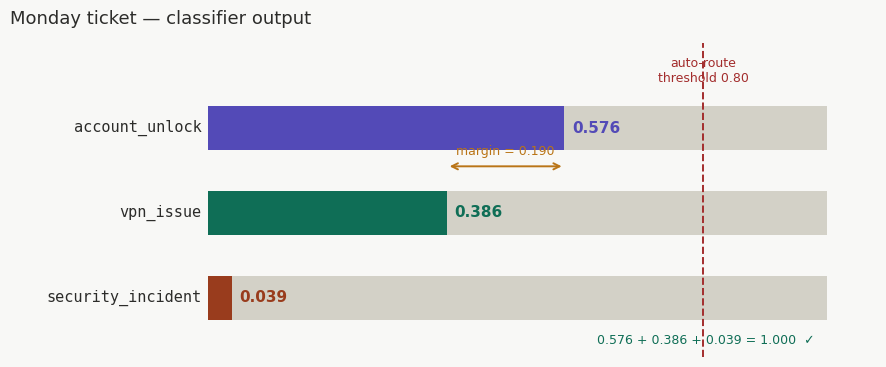

In [2]:
fig1, ax = plt.subplots(figsize=(9, 3.8))
fig1.patch.set_facecolor(BG)
ax.set_facecolor(BG)

intents = ['account_unlock', 'vpn_issue', 'security_incident']
probs   = [0.576, 0.386, 0.039]
colors  = [PURPLE, TEAL, CORAL]
y_pos   = [2, 1, 0]

for y, p, c, label in zip(y_pos, probs, colors, intents):
    # background track
    ax.barh(y, 1.0, color=BORDER, height=0.52, left=0, zorder=1)
    # probability bar
    ax.barh(y, p,   color=c,      height=0.52, left=0, zorder=2)
    # intent label (left)
    ax.text(-0.01, y, label, ha='right', va='center', fontsize=11,
            color=TEXT, fontfamily='monospace')
    # value (right of bar)
    ax.text(p + 0.012, y, f'{p:.3f}', ha='left', va='center',
            fontsize=11, fontweight='bold', color=c)

# Auto-route threshold line
ax.axvline(0.80, color=RED, linewidth=1.4, linestyle='--', zorder=3)
ax.text(0.80, 2.55, 'auto-route\nthreshold 0.80',
        ha='center', fontsize=9, color=RED)

# Margin annotation
ax.annotate('', xy=(0.386, 1.55), xytext=(0.576, 1.55),
            arrowprops=dict(arrowstyle='<->', color=AMBER, lw=1.4))
ax.text(0.481, 1.68, 'margin = 0.190',
        ha='center', fontsize=9, color=AMBER)

# Sum check footer
ax.text(0.98, -0.55, '0.576 + 0.386 + 0.039 = 1.000  ✓',
        ha='right', fontsize=9, color=TEAL)

ax.set_xlim(-0.32, 1.08)
ax.set_ylim(-0.7, 3.0)
ax.axis('off')
ax.set_title('Monday ticket — classifier output', fontsize=13,
             fontweight='500', color=TEXT, pad=14, loc='left')

fig1.tight_layout()
save(fig1, 'fig1_classifier_output.png')
plt.show()

---
## Figure 2 — Confidence ladder

Four routing tiers as horizontal bands.  
The arrow marks where the Monday ticket (0.576) lands — clarification queue, not auto-route.

Saved: fig2_confidence_ladder.png


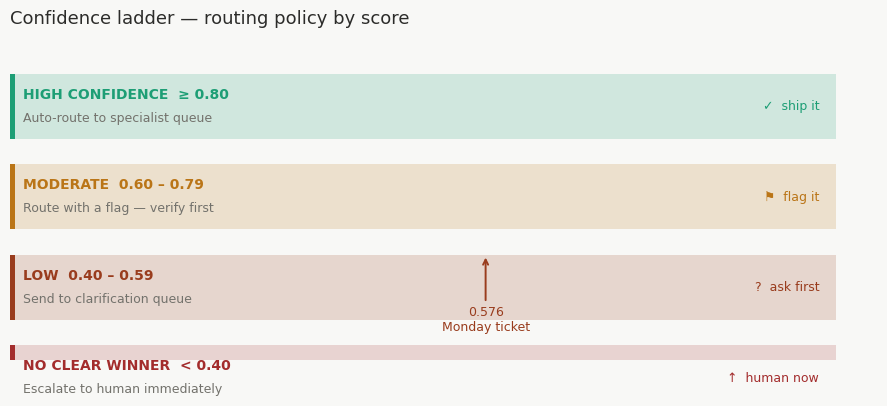

In [3]:
fig2, ax = plt.subplots(figsize=(9, 4.2))
fig2.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# (lo, hi, color, title, subtitle, action_label)
bands = [
    (0.80, 1.00, GREEN, 'HIGH CONFIDENCE  ≥ 0.80',
     'Auto-route to specialist queue',    '✓  ship it'),
    (0.60, 0.80, AMBER, 'MODERATE  0.60 – 0.79',
     'Route with a flag — verify first',  '⚑  flag it'),
    (0.40, 0.60, CORAL, 'LOW  0.40 – 0.59',
     'Send to clarification queue',       '?  ask first'),
    (0.00, 0.40, RED,   'NO CLEAR WINNER  < 0.40',
     'Escalate to human immediately',     '↑  human now'),
]

for i, (lo, hi, c, title, subtitle, action) in enumerate(bands):
    y = 3 - i
    ax.barh(y, 1.0,   height=0.72, color=c, alpha=0.18, left=0)
    ax.barh(y, 0.006, height=0.72, color=c, left=0)          # left accent
    ax.text(0.016, y + 0.13, title,    fontsize=10, fontweight='bold',
            color=c,    va='center')
    ax.text(0.016, y - 0.13, subtitle, fontsize=9,
            color=MUTED, va='center')
    ax.text(0.98,  y,        action,   fontsize=9,
            color=c, ha='right', va='center')

# Monday ticket marker
monday_x = 0.576
ax.annotate(
    '0.576\nMonday ticket',
    xy=(monday_x, 1.36), xytext=(monday_x, 0.52),
    fontsize=9, color=CORAL, ha='center',
    arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.4)
)

ax.set_xlim(0, 1.05)
ax.set_ylim(0.2, 3.7)
ax.axis('off')
ax.set_title('Confidence ladder — routing policy by score', fontsize=13,
             fontweight='500', color=TEXT, pad=14, loc='left')

fig2.tight_layout()
save(fig2, 'fig2_confidence_ladder.png')
plt.show()

---
## Figure 3 — Expected value and staffing projection

Left panel: stacked bar showing the three components of E[handle time].  
Right panel: agent-hours and agent count as ticket volume grows.

Saved: fig3_expected_value.png


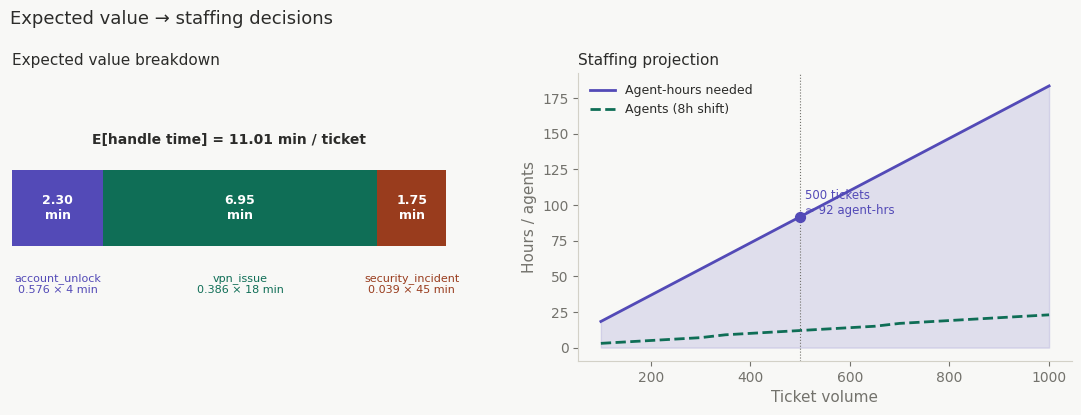

In [4]:
fig3, axes = plt.subplots(1, 2, figsize=(11, 4.2))
fig3.patch.set_facecolor(BG)

# ── Left: expected value breakdown ────────────────────────────────────────────
ax3a = axes[0]
ax3a.set_facecolor(BG)

values  = [0.576 * 4, 0.386 * 18, 0.039 * 45]   # [2.304, 6.948, 1.755]
colors3 = [PURPLE, TEAL, CORAL]
xlabels = [
    'account_unlock\n0.576 × 4 min',
    'vpn_issue\n0.386 × 18 min',
    'security_incident\n0.039 × 45 min',
]

ax3a.barh([0, 0, 0], values, color=colors3, height=0.45,
          left=[0, values[0], values[0] + values[1]])

cumsum = 0
for val, c, label in zip(values, colors3, xlabels):
    ax3a.text(cumsum + val / 2, 0,
              f'{val:.2f}\nmin', ha='center', va='center',
              fontsize=9, color='white', fontweight='bold')
    ax3a.text(cumsum + val / 2, -0.38, label,
              ha='center', va='top', fontsize=8, color=c)
    cumsum += val

total = sum(values)
ax3a.text(total / 2, 0.38,
          f'E[handle time] = {total:.2f} min / ticket',
          ha='center', fontsize=10, fontweight='bold', color=TEXT)

ax3a.set_xlim(0, total + 1.5)
ax3a.set_ylim(-0.9, 0.8)
ax3a.axis('off')
ax3a.set_title('Expected value breakdown', fontsize=11,
               fontweight='500', color=TEXT, loc='left')

# ── Right: staffing projection ────────────────────────────────────────────────
ax3b = axes[1]
ax3b.set_facecolor(BG)

volumes     = np.arange(100, 1001, 50)
ev          = 11.01
agent_hours = volumes * ev / 60
agents_8h   = np.ceil(agent_hours / 8)

ax3b.fill_between(volumes, agent_hours, alpha=0.15, color=PURPLE)
ax3b.plot(volumes, agent_hours, color=PURPLE, linewidth=2,
          label='Agent-hours needed')
ax3b.plot(volumes, agents_8h,   color=TEAL,   linewidth=2,
          linestyle='--', label='Agents (8h shift)')

# Highlight 500-ticket mark
ax3b.axvline(500, color=MUTED, linewidth=0.8, linestyle=':')
ax3b.scatter([500], [500 * ev / 60], color=PURPLE, s=50, zorder=5)
ax3b.text(510, 500 * ev / 60,
          f'500 tickets\n≈ {500 * ev / 60:.0f} agent-hrs',
          fontsize=8.5, color=PURPLE, va='bottom')

ax3b.set_xlabel('Ticket volume', color=MUTED)
ax3b.set_ylabel('Hours / agents', color=MUTED)
ax3b.legend(fontsize=9, frameon=False)
ax3b.spines['bottom'].set_visible(True)
ax3b.spines['bottom'].set_color(BORDER)
ax3b.spines['left'].set_visible(True)
ax3b.spines['left'].set_color(BORDER)
ax3b.set_title('Staffing projection', fontsize=11,
               fontweight='500', color=TEXT, loc='left')

fig3.suptitle('Expected value → staffing decisions', fontsize=13,
              fontweight='500', color=TEXT, x=0.02, ha='left')
fig3.tight_layout()
save(fig3, 'fig3_expected_value.png')
plt.show()

---
## Figure 4 — Misrouting reality

How many tickets land in the wrong queue per 1,000, at each confidence level.  
The Monday ticket at 0.576 means ~424 wrong routes per 1,000 — silently, with no alert.

Saved: fig4_misroute_reality.png


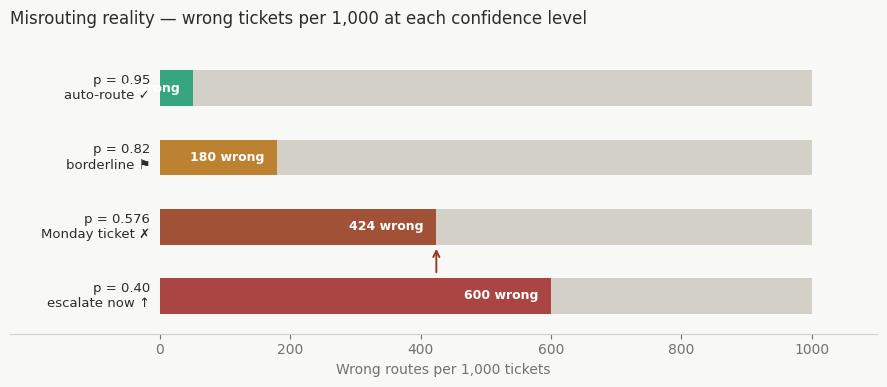

In [5]:
fig4, ax = plt.subplots(figsize=(9, 4.0))
fig4.patch.set_facecolor(BG)
ax.set_facecolor(BG)

confidences  = [0.95, 0.82, 0.576, 0.40]
wrong_per_1k = [int((1 - p) * 1000) for p in confidences]
bar_colors   = [GREEN, AMBER, CORAL, RED]
row_labels   = [
    'p = 0.95\nauto-route ✓',
    'p = 0.82\nborderline ⚑',
    'p = 0.576\nMonday ticket ✗',
    'p = 0.40\nescalate now ↑',
]
y_pos = [3, 2, 1, 0]

for y, wrong, c, label in zip(y_pos, wrong_per_1k, bar_colors, row_labels):
    # background track (full 1000)
    ax.barh(y, 1000, height=0.52, color=BORDER, left=0, zorder=1)
    # wrong bar
    ax.barh(y, wrong, height=0.52, color=c, alpha=0.85, left=0, zorder=2)
    # row label (left)
    ax.text(-15, y, label, ha='right', va='center', fontsize=9.5, color=TEXT)
    # count inside bar
    ax.text(wrong - 20, y, f'{wrong} wrong',
            ha='right', va='center', fontsize=9, color='white', fontweight='bold')

# Subtle arrow on Monday ticket row
ax.annotate('', xy=(424, 0.72), xytext=(424, 0.3),
            arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.4))

ax.set_xlim(-230, 1100)
ax.set_ylim(-0.55, 3.65)
ax.set_xlabel('Wrong routes per 1,000 tickets', color=MUTED, fontsize=10)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color(BORDER)
ax.set_xticks([0, 200, 400, 600, 800, 1000])
ax.tick_params(left=False, labelleft=False)
ax.set_title(
    'Misrouting reality — wrong tickets per 1,000 at each confidence level',
    fontsize=12, fontweight='500', color=TEXT, pad=14, loc='left'
)

fig4.tight_layout()
save(fig4, 'fig4_misroute_reality.png')
plt.show()

---
## All four figures in one cell

Run this to regenerate and save all four plots at once.

In [6]:
# Re-run all four figure cells above, or call their code here.
# Each save() call writes a PNG to the current working directory.
#
# Output files:
#   fig1_classifier_output.png
#   fig2_confidence_ladder.png
#   fig3_expected_value.png
#   fig4_misroute_reality.png
#
# For blog use: set dpi=300 in save() for print-quality output.
print('Run each figure cell above to generate the plots.')

Run each figure cell above to generate the plots.
